# Sprint 1 — Análisis Exploratorio de Datos (EDA)
## Proyecto: Productividad Asesores de Negocios — Clasificación de Riesgo de Cartera

---

### ¿Qué hace este notebook?

Este notebook cumple el **criterio de cierre del Sprint 1**: documentar la calidad real
de los datos, confirmar los hallazgos de la auditoría de tesis y tomar decisiones de
diseño explícitas antes de construir cualquier modelo.

### Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 1. Carga de datos | Lectura desde DuckDB o CSV fuente |
| 2. Calidad de datos | Nulos, tipos, cardinalidad por columna |
| 3. Variable objetivo | Distribución de `DIAS_MORA_RANGO` y desbalance real |
| 4. Cobertura temporal | Volumen de registros por período |
| 5. Variables numéricas | Estadísticas descriptivas y detección de outliers |
| 6. Variables categóricas | Frecuencias, valores únicos, inconsistencias |
| 7. Leakage confirmado | Verificación de PASE1, PASE15, PASE30 |
| 8. Decisiones de diseño | Registro formal de decisiones para METHODOLOGY.md |

### Advertencias metodológicas activas

> ⚠️ **Leakage:** PASE1, PASE15, PASE30 son contemporáneas al target — excluidas del modelo.  
> ⚠️ **Desbalance:** La métrica de evaluación es **macro F1**, no accuracy global.  
> ⚠️ **Fairness:** SEXO, EDAD, ESTADO_CIVIL requieren análisis de equidad antes de usarse en el modelo (Sprint 6).  
> ⚠️ **Outliers:** Se documentan en este sprint pero NO se filtran aquí — eso ocurre en Sprint 3 (feature engineering).


## 1. Configuración del entorno

Cargamos las librerías necesarias y configuramos las opciones de visualización.
Todas las rutas son relativas a la raíz del proyecto para garantizar portabilidad.


In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Datos y cálculo ───────────────────────────────────────────────────────────
import duckdb           # Base de datos columnar local (sin servidor)
import pandas as pd     # Manipulación de DataFrames
import numpy as np      # Operaciones numéricas

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # Gráficas estáticas (boxplots, histogramas)
import plotly.express as px              # Gráficas interactivas (barras, líneas)
import plotly.graph_objects as go        # Control fino de gráficas Plotly

# ── Suprimir warnings no críticos ────────────────────────────────────────────
warnings.filterwarnings("ignore")

# ── Opciones de visualización en pandas ──────────────────────────────────────
pd.set_option("display.max_columns", None)    # Mostrar todas las columnas
pd.set_option("display.max_rows", 120)        # Mostrar hasta 120 filas
pd.set_option("display.float_format", "{:,.4f}".format)  # 4 decimales en floats

# ── Estilo de gráficas matplotlib ────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ── Rutas del proyecto (relativas al notebook en /notebooks/) ─────────────────
DB_PATH    = Path("../data/advisor_risk.duckdb")   # Base de datos DuckDB
RAW_DIR    = Path("../data/raw")                   # Archivos CSV fuente (confidenciales)
FIG_DIR    = Path("../reports/figures")            # Directorio de figuras exportadas
TABLE_NAME = "tabla_hist_asesores"                 # Nombre de la tabla en DuckDB

# Crear directorio de figuras si no existe
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Librerías cargadas correctamente")
print(f"  DuckDB ya existe: {DB_PATH.exists()}")
print(f"  Directorio de figuras: {FIG_DIR.resolve()}")


✓ Librerías cargadas correctamente
  DuckDB ya existe: True
  Directorio de figuras: C:\Users\Marin\Documents\PROYECTO ML_OPS\productividad-asesores-negocios\reports\figures


## 2. Carga de datos

### 2.1 Schema de la tabla

Los archivos CSV fuente **no tienen encabezado** — los nombres de columna
provienen del DDL original de SQL Server (`CREATE TABLE Tabla_Hist_Asesores`).

Las fechas están almacenadas como enteros en formato `YYYYMMDD` y se convierten
a `datetime` durante la carga para habilitar el split temporal en Sprint 2.


In [2]:
# ── Nombres de columna en el orden exacto del DDL original ───────────────────
# Fuente: CREATE TABLE Tabla_Hist_Asesores (SQL Server, tesis IPN 2020)
COLUMN_NAMES = [
    "HOY",                      # Fecha de corte del reporte (YYYYMMDD → DATE)
    "REGION",                   # Región geográfica de la sucursal
    "CODIGO_SUCURSAL",          # ID numérico de sucursal
    "SUCURSAL",                 # Nombre de la sucursal
    "COORDINADOR",              # Nombre del coordinador del asesor
    "CODIGO_ASESOR",            # ID único del asesor ← unidad de análisis principal
    "ASESOR",                   # Nombre del asesor
    "DIA_PAGO",                 # Día de pago asignado al grupo (1-7)
    "CICLO",                    # Número de ciclo crediticio del grupo
    "RANGO_CICLO",              # Ciclo agrupado en rangos categóricos
    "GRUPOS",                   # Número de grupos que gestiona el asesor
    "CLIENTES",                 # Número de clientes activos
    "PRESTAMO",                 # Monto promedio de préstamo
    "CLIENTES_PRESTAMO",        # Clientes con préstamo activo
    "CARTERA_HOY",              # Saldo de cartera en la fecha de corte
    "CARTERA_SEMANT",           # Saldo de cartera la semana anterior
    "INCREMENTO_CARTERA",       # Variación de cartera semana sobre semana
    "ATRASO",                   # Monto en atraso
    "SEMANA_ACTUAL",            # Número de semana del año
    "SEMANA_ACTUAL_RANGO",      # Semana agrupada en rangos — requiere limpieza
    "TASA_PROM",                # Tasa de interés promedio de la cartera
    "PROVISION_HOY",            # Provisión acumulada hoy
    "PROVISION_SEMANT",         # Provisión semana anterior
    "GASTO_PROVISION_SEMANAL",  # Gasto en provisión de la semana
    "PASE1",    # ❌ LEAKAGE — % cartera con 1 día mora (contemporáneo al target)
    "PASE15",   # ❌ LEAKAGE — % cartera con 15 días mora (contemporáneo al target)
    "PASE30",   # ❌ LEAKAGE — % cartera con 30 días mora (contemporáneo al target)
    "CLIENTES_NUEVOS",              # Clientes nuevos en el período
    "DESEMBOLSO_CLIENTES_NUEVOS",   # Monto desembolsado a clientes nuevos
    "DIAS_MORA",                    # Días de mora promedio ← base del target
    "DIAS_MORA_RANGO",              # ← TARGET: categoría de mora del asesor
    "NUMERO_EMPLEADO",  # ID RH del asesor
    "NOMBRE",           # Nombre completo (mismo que ASESOR, redundante)
    "PUESTO",           # Cargo formal en la institución
    "PRODUCTO",         # Tipo de producto crediticio
    "N_SUCURSAL",       # ID alternativo de sucursal
    "AREA",             # Área geográfica (nivel superior a REGION)
    "FECHA_ALTA",       # Fecha de contratación del asesor (YYYYMMDD → DATE)
    "FECHA_BAJA",       # Fecha de baja del asesor, si aplica (YYYYMMDD → DATE)
    "TIPO_BAJA",        # Tipo de baja: voluntaria, involuntaria, etc.
    "MOTIVO_BAJA",      # Motivo específico de la baja
    "FECHA_NACIMIENTO", # Fecha de nacimiento del asesor (YYYYMMDD → DATE)
    "EDAD",             # Edad calculada en el momento del corte
    "SEXO",             # ⚠️ FAIRNESS — género del asesor
    "ESTADO_CIVIL",     # ⚠️ FAIRNESS — estado civil del asesor
    "EXP_MICROFINANZAS",# Experiencia previa en microfinanzas (categórica)
    "NIVEL_ESTUDIOS",   # Máximo nivel de estudios alcanzado
]

# ── Columnas con fechas en formato YYYYMMDD ───────────────────────────────────
DATE_COLUMNS = ["HOY", "FECHA_ALTA", "FECHA_BAJA", "FECHA_NACIMIENTO"]

# ── Columnas numéricas enteras ────────────────────────────────────────────────
INT_COLS = [
    "CODIGO_SUCURSAL", "CODIGO_ASESOR", "DIA_PAGO", "CICLO",
    "GRUPOS", "CLIENTES", "SEMANA_ACTUAL", "PASE1", "PASE15", "PASE30",
    "CLIENTES_NUEVOS", "DESEMBOLSO_CLIENTES_NUEVOS",
    "DIAS_MORA", "NUMERO_EMPLEADO", "N_SUCURSAL", "EDAD",
]

# ── Columnas numéricas flotantes ──────────────────────────────────────────────
FLOAT_COLS = [
    "PRESTAMO", "CLIENTES_PRESTAMO",
    "CARTERA_HOY", "CARTERA_SEMANT", "INCREMENTO_CARTERA", "ATRASO",
    "TASA_PROM", "PROVISION_HOY", "PROVISION_SEMANT", "GASTO_PROVISION_SEMANAL",
]

print(f"✓ Schema definido: {len(COLUMN_NAMES)} columnas")
print(f"  Fechas a convertir : {DATE_COLUMNS}")
print(f"  Columnas enteras   : {len(INT_COLS)}")
print(f"  Columnas flotantes : {len(FLOAT_COLS)}")


✓ Schema definido: 47 columnas
  Fechas a convertir : ['HOY', 'FECHA_ALTA', 'FECHA_BAJA', 'FECHA_NACIMIENTO']
  Columnas enteras   : 16
  Columnas flotantes : 10


In [3]:
# Diagnóstico rápido — ver las primeras 3 filas crudas sin procesar
import pandas as pd
from pathlib import Path

f = Path("../data/raw/NUEVA_CARGA_1.csv")

# Leer sin nombres ni tipos — ver exactamente qué hay
df_raw = pd.read_csv(f, header=None, encoding="latin-1", sep="\t", nrows=3)
print(f"Columnas detectadas: {len(df_raw.columns)}")
print(f"\nPrimeras 3 filas crudas:")
print(df_raw.to_string())
print(f"\nColumna 0 (HOY) valores: {df_raw[0].tolist()}")
print(f"Columna 0 dtype: {df_raw[0].dtype}")

Columnas detectadas: 47

Primeras 3 filas crudas:
         0          1   2         3                         4     5                             6   7   8              9   10  11  12  13           14           15           16  17  18                  19       20         21         22         23  24  25  26  27  28  29                30    31                            32                  33              34  35         36        37        38   39        40        41  42 43      44  45            46
0  20180103  Altiplano  23  Tehuacán  C. Liliana Cordova Rosas  3754  Juan Manuel Garcia Rodriguez   3  12  CICLO_MAYOR_5   1  13   0   0  45,866.4200  53,091.6400  -7,225.2200   0   9  SEMANA_ACTUAL_9_11 108.7600   672.8500   778.8400  -105.9900   0   0   0   0   0   0  CARTERA_A_TIEMPO  3754  GARCIA RODRIGUEZ JUAN MANUEL  ASESOR DE NEGOCIOS  CREDITO GRUPAL  23  COMERCIAL  20140213  20180130  VOL  ABANDONO  19920329  25  H  CASADO  NO  PREPARATORIA
1  20180103  Altiplano  23  Tehuacán  C. L

In [4]:
# Diagnóstico completo — escanear todo el archivo para encontrar filas problemáticas
import pandas as pd
from pathlib import Path

f = Path("../data/raw/NUEVA_CARGA_1.csv")

COLUMN_NAMES_LOCAL = [
    "HOY", "REGION", "CODIGO_SUCURSAL", "SUCURSAL", "COORDINADOR",
    "CODIGO_ASESOR", "ASESOR", "DIA_PAGO", "CICLO", "RANGO_CICLO",
    "GRUPOS", "CLIENTES", "PRESTAMO", "CLIENTES_PRESTAMO",
    "CARTERA_HOY", "CARTERA_SEMANT", "INCREMENTO_CARTERA", "ATRASO",
    "SEMANA_ACTUAL", "SEMANA_ACTUAL_RANGO", "TASA_PROM",
    "PROVISION_HOY", "PROVISION_SEMANT", "GASTO_PROVISION_SEMANAL",
    "PASE1", "PASE15", "PASE30",
    "CLIENTES_NUEVOS", "DESEMBOLSO_CLIENTES_NUEVOS",
    "DIAS_MORA", "DIAS_MORA_RANGO",
    "NUMERO_EMPLEADO", "NOMBRE", "PUESTO", "PRODUCTO",
    "N_SUCURSAL", "AREA", "FECHA_ALTA", "FECHA_BAJA",
    "TIPO_BAJA", "MOTIVO_BAJA", "FECHA_NACIMIENTO", "EDAD",
    "SEXO", "ESTADO_CIVIL", "EXP_MICROFINANZAS", "NIVEL_ESTUDIOS",
]

INT_COLS_LOCAL = [
    "CODIGO_SUCURSAL", "CODIGO_ASESOR", "DIA_PAGO", "CICLO",
    "GRUPOS", "CLIENTES", "SEMANA_ACTUAL", "PASE1", "PASE15", "PASE30",
    "CLIENTES_NUEVOS", "DESEMBOLSO_CLIENTES_NUEVOS",
    "DIAS_MORA", "NUMERO_EMPLEADO", "N_SUCURSAL", "EDAD",
]

# Leer archivo completo
print("Leyendo archivo completo...")
df_test = pd.read_csv(
    f, header=None, names=COLUMN_NAMES_LOCAL,
    encoding="latin-1", sep="\t", dtype=str
)
print(f"Total filas: {len(df_test):,}\n")

# Verificar cuántas columnas tiene cada fila
n_cols_por_fila = df_test.notna().sum(axis=1)
filas_raras = df_test[n_cols_por_fila != 47]
print(f"Filas con número incorrecto de columnas: {len(filas_raras):,}")
if len(filas_raras) > 0:
    print(f"Índices: {filas_raras.index[:10].tolist()}")
    print(f"\nEjemplo fila rara (índice {filas_raras.index[0]}):")
    print(df_test.iloc[filas_raras.index[0]].to_string())

# Buscar columnas con valores no numéricos en todo el archivo
print("\n=== ESCANEO COMPLETO DE COLUMNAS INT ===\n")
problemas_encontrados = False
for col in INT_COLS_LOCAL:
    serie_orig = df_test[col]
    serie_num  = pd.to_numeric(serie_orig, errors="coerce")
    mask_fallo = serie_num.isna() & serie_orig.notna()
    n_fallos   = mask_fallo.sum()
    if n_fallos > 0:
        problemas_encontrados = True
        vals = serie_orig[mask_fallo].unique()[:5]
        idxs = serie_orig[mask_fallo].index[:5].tolist()
        print(f"  ❌ {col:<35} {n_fallos:,} valores problemáticos")
        print(f"     Valores : {vals}")
        print(f"     Índices : {idxs}")
        # Mostrar la fila completa del primer problema
        print(f"     Fila completa (índice {idxs[0]}):")
        print(f"     {df_test.iloc[idxs[0]][['HOY','CODIGO_ASESOR', col]].to_dict()}\n")

if not problemas_encontrados:
    print("  ✓ Ninguna columna INT tiene valores problemáticos en el archivo completo")
    print("\n  → El error debe estar en la conversión a Int64, no en los datos.")
    print("  → Probaremos conversión alternativa.")

Leyendo archivo completo...
Total filas: 482,126

Filas con número incorrecto de columnas: 345,660
Índices: [4, 62, 63, 64, 65, 66, 67, 68, 69, 70]

Ejemplo fila rara (índice 4):
HOY                                               20180103
REGION                                           Altiplano
CODIGO_SUCURSAL                                         23
SUCURSAL                                          Tehuacán
COORDINADOR                       C. Liliana Cordova Rosas
CODIGO_ASESOR                                         3754
ASESOR                        Juan Manuel Garcia Rodriguez
DIA_PAGO                                                 4
CICLO                                                    3
RANGO_CICLO                                        CICLO_3
GRUPOS                                                   1
CLIENTES                                                 9
PRESTAMO                                                 0
CLIENTES_PRESTAMO                                     

In [5]:
# Diagnóstico de distribución de columnas por fila
import pandas as pd
from pathlib import Path

f = Path("../data/raw/NUEVA_CARGA_1.csv")

COLUMN_NAMES_LOCAL = [
    "HOY", "REGION", "CODIGO_SUCURSAL", "SUCURSAL", "COORDINADOR",
    "CODIGO_ASESOR", "ASESOR", "DIA_PAGO", "CICLO", "RANGO_CICLO",
    "GRUPOS", "CLIENTES", "PRESTAMO", "CLIENTES_PRESTAMO",
    "CARTERA_HOY", "CARTERA_SEMANT", "INCREMENTO_CARTERA", "ATRASO",
    "SEMANA_ACTUAL", "SEMANA_ACTUAL_RANGO", "TASA_PROM",
    "PROVISION_HOY", "PROVISION_SEMANT", "GASTO_PROVISION_SEMANAL",
    "PASE1", "PASE15", "PASE30",
    "CLIENTES_NUEVOS", "DESEMBOLSO_CLIENTES_NUEVOS",
    "DIAS_MORA", "DIAS_MORA_RANGO",
    "NUMERO_EMPLEADO", "NOMBRE", "PUESTO", "PRODUCTO",
    "N_SUCURSAL", "AREA", "FECHA_ALTA", "FECHA_BAJA",
    "TIPO_BAJA", "MOTIVO_BAJA", "FECHA_NACIMIENTO", "EDAD",
    "SEXO", "ESTADO_CIVIL", "EXP_MICROFINANZAS", "NIVEL_ESTUDIOS",
]

df_test = pd.read_csv(
    f, header=None, names=COLUMN_NAMES_LOCAL,
    encoding="latin-1", sep="\t", dtype=str
)

# Contar tabs reales por línea leyendo el archivo crudo
print("Contando tabs por línea en el archivo crudo...")
conteo = {}
with open(f, "r", encoding="latin-1") as fh:
    for i, linea in enumerate(fh):
        n_tabs = linea.count("\t")
        conteo[n_tabs] = conteo.get(n_tabs, 0) + 1

print("\nDistribución de tabuladores por línea:")
print(f"{'# tabs':<10} {'# líneas':>12} {'% del total':>12}")
print("─" * 36)
total = sum(conteo.values())
for n_tabs in sorted(conteo.keys()):
    pct = conteo[n_tabs] / total * 100
    print(f"{n_tabs:<10} {conteo[n_tabs]:>12,} {pct:>11.1f}%")

print(f"\nTotal líneas: {total:,}")
print(f"Se esperan 46 tabs por línea (47 columnas)")

Contando tabs por línea en el archivo crudo...

Distribución de tabuladores por línea:
# tabs         # líneas  % del total
────────────────────────────────────
46              482,126       100.0%

Total líneas: 482,126
Se esperan 46 tabs por línea (47 columnas)


### 2.2 Funciones de carga y conversión de tipos

Separamos la lógica de lectura de CSV y la conversión de tipos en funciones
reutilizables. Esto garantiza que el mismo proceso se aplique idénticamente
a ambos archivos antes de concatenarlos.


In [6]:
def cargar_csv(filepath: Path) -> pd.DataFrame:
    """
    Lee un archivo CSV fuente con los parámetros conocidos del dataset.
    
    Parámetros fijos (determinados por inspección del archivo real):
      - sin encabezado (header=None)
      - encoding latin-1 (ISO-8859-1) — contiene acentos en nombres de lugares
      - separador coma
      - dtype=str para evitar inferencia incorrecta de tipos con nulos
    """
    df = pd.read_csv(
        filepath,
        header=None,           # Los archivos NO tienen fila de encabezado
        names=COLUMN_NAMES,    # Nombres fijos del DDL original
        encoding="latin-1",    # Encoding confirmado: ISO-8859-1
        sep="\t",               # Separador confirmado por inspección
        low_memory=False,      # Evita advertencias en archivos grandes con tipos mixtos
        dtype=str,             # Leer todo como string; tipos se aplican en cast_types()
    )
    return df


def aplicar_tipos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte cada columna al tipo correcto después de la lectura.
    
    Usa float64 para columnas enteras con posibles nulos — evita el problema
    de cast a Int64 nullable que falla con versiones específicas de pandas.
    Los valores se ven como 3754.0 en lugar de 3754, pero esto no afecta
    ni el modelado ni DuckDB (que los almacena correctamente como INTEGER).
    """
    # Numéricos — todo a float64 (maneja NaN sin problemas de cast)
    for col in INT_COLS + FLOAT_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fechas YYYYMMDD → datetime
    for col in DATE_COLUMNS:
        df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")

    return df


# ── Carga efectiva: DuckDB si existe, CSV si no ───────────────────────────────
if not DB_PATH.exists():
    # Primera ejecución: leer los dos CSV y guardar en DuckDB
    print("DuckDB no encontrado — construyendo desde archivos CSV fuente...")
    frames = []
    for f in sorted(RAW_DIR.glob("*.csv")):
        print(f"  Leyendo {f.name} ...", end=" ")
        df_tmp = cargar_csv(f)
        df_tmp = aplicar_tipos(df_tmp)
        print(f"{len(df_tmp):,} filas")
        frames.append(df_tmp)
    
    # Concatenar y ordenar cronológicamente por HOY
    df = pd.concat(frames, ignore_index=True).sort_values("HOY").reset_index(drop=True)
    
    # Verificar cobertura temporal por archivo usando el DataFrame ya cargado
    print("\n  Cobertura temporal por archivo:")
    for f, df_tmp in zip(sorted(RAW_DIR.glob("*.csv")), frames):
        hoy_min = df_tmp["HOY"].min().date()
        hoy_max = df_tmp["HOY"].max().date()
        print(f"    {f.name}: {hoy_min} → {hoy_max}")
    
    # Guardar en DuckDB para lecturas futuras más rápidas
    conn = duckdb.connect(str(DB_PATH))
    conn.register("_tmp", df)
    conn.execute(f"CREATE TABLE {TABLE_NAME} AS SELECT * FROM _tmp")
    conn.unregister("_tmp")
    conn.close()
    print(f"\n✓ DuckDB creado en: {DB_PATH}")

else:
    # Ejecuciones posteriores: leer directo desde DuckDB (mucho más rápido)
    print("DuckDB encontrado — cargando directamente (más rápido que CSV)...")
    conn = duckdb.connect(str(DB_PATH), read_only=True)
    df   = conn.execute(f"SELECT * FROM {TABLE_NAME}").df()
    conn.close()
    
    # DuckDB puede devolver fechas como object — re-convertir para garantizar dtype
    for col in DATE_COLUMNS:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# ── Resumen de carga ──────────────────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"  Dataset cargado correctamente")
print(f"  Filas       : {len(df):,}")
print(f"  Columnas    : {df.shape[1]}")
print(f"  Período     : {df['HOY'].min().date()} → {df['HOY'].max().date()}")
print(f"  Asesores    : {df['CODIGO_ASESOR'].nunique():,} únicos")
print(f"  Sucursales  : {df['SUCURSAL'].nunique():,} únicas")
print(f"  Regiones    : {df['REGION'].nunique():,} únicas")
print(f"{'═'*55}")


DuckDB encontrado — cargando directamente (más rápido que CSV)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


═══════════════════════════════════════════════════════
  Dataset cargado correctamente
  Filas       : 1,218,831
  Columnas    : 47
  Período     : 2016-06-22 → 2019-01-30
  Asesores    : 2,004 únicos
  Sucursales  : 51 únicas
  Regiones    : 9 únicas
═══════════════════════════════════════════════════════


## 3. Calidad de datos

Inventario completo de todas las columnas: tipo inferido, cantidad y porcentaje
de nulos, cardinalidad (valores únicos) y un ejemplo representativo.

Esta tabla es la base para decidir qué columnas se incluyen en el modelo,
cuáles requieren imputación y cuáles se excluyen directamente.


In [7]:
def tabla_calidad(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un inventario de calidad para cada columna del DataFrame.
    
    Para cada columna reporta:
      - tipo: dtype de pandas
      - nulos: cantidad de valores faltantes (NaN / NaT / None)
      - % nulos: porcentaje sobre el total de filas
      - cardinalidad: número de valores únicos (excluyendo nulos)
      - ejemplo: primer valor no nulo como referencia
    """
    n = len(df)
    registros = []
    for col in df.columns:
        n_nulos   = int(df[col].isna().sum())
        pct_nulos = round(n_nulos / n * 100, 1)
        card      = int(df[col].nunique(dropna=True))
        # Tomar el primer valor no nulo como ejemplo
        no_nulos  = df[col].dropna()
        ejemplo   = str(no_nulos.iloc[0]) if len(no_nulos) > 0 else "— todo nulo —"
        registros.append({
            "columna"      : col,
            "tipo"         : str(df[col].dtype),
            "nulos"        : n_nulos,
            "% nulos"      : pct_nulos,
            "cardinalidad" : card,
            "ejemplo"      : ejemplo,
        })
    return pd.DataFrame(registros)


qc = tabla_calidad(df)

# ── Mostrar separado: columnas con nulos vs sin nulos ─────────────────────────
con_nulos    = qc[qc["nulos"] > 0].reset_index(drop=True)
sin_nulos    = qc[qc["nulos"] == 0].reset_index(drop=True)

print(f"Columnas CON nulos   : {len(con_nulos)}")
print(f"Columnas SIN nulos   : {len(sin_nulos)}")
print(f"Total columnas       : {len(qc)}")

print("\n=== COLUMNAS CON NULOS (ordenadas por % nulos desc) ===")
display(con_nulos.sort_values("% nulos", ascending=False).reset_index(drop=True))

print("\n=== COLUMNAS SIN NULOS ===")
display(sin_nulos)


Columnas CON nulos   : 20
Columnas SIN nulos   : 27
Total columnas       : 47

=== COLUMNAS CON NULOS (ordenadas por % nulos desc) ===


,columna,tipo,nulos,% nulos,cardinalidad,ejemplo
0,MOTIVO_BAJA,object,889141,73.0000,20,ABANDONO
1,FECHA_BAJA,datetime64[ns],563441,46.2000,542,2016-08-06 00:00:00
2,ESTADO_CIVIL,object,131847,10.8000,6,DIVORCIADO
3,NIVEL_ESTUDIOS,object,129178,10.6000,8,UNIVERSIDAD TRUNCA
4,FECHA_NACIMIENTO,datetime64[ns],77013,6.3000,1648,1987-10-17 00:00:00
5,AREA,object,75873,6.2000,4,COMERCIAL
6,N_SUCURSAL,float64,75873,6.2000,51,38.0
7,PRODUCTO,object,75873,6.2000,2,CREDITO GRUPAL
8,FECHA_ALTA,datetime64[ns],75873,6.2000,790,2015-06-23 00:00:00
9,NUMERO_EMPLEADO,float64,75873,6.2000,1852,4619.0



=== COLUMNAS SIN NULOS ===


,columna,tipo,nulos,% nulos,cardinalidad,ejemplo
0,HOY,datetime64[ns],0,0.0000,137,2016-06-22 00:00:00
1,CODIGO_SUCURSAL,int64,0,0.0000,51,38
2,COORDINADOR,object,0,0.0000,311,Omar Garcia Rodriguez
3,CODIGO_ASESOR,int64,0,0.0000,2004,4619
4,DIA_PAGO,int64,0,0.0000,7,1
5,CICLO,int64,0,0.0000,35,1
6,RANGO_CICLO,object,0,0.0000,6,CICLO_1
7,GRUPOS,int64,0,0.0000,9,1
8,CLIENTES,int64,0,0.0000,46,8
9,PRESTAMO,float64,0,0.0000,1018,0.0


## 4. Variable objetivo — `DIAS_MORA_RANGO`

Esta es la variable que el modelo deberá predecir. Documentamos:

1. **Cuántas clases existen realmente** en el dataset completo (la tesis reportaba 8; en la muestra se detectaron al menos 2)
2. **Distribución de frecuencias** para cuantificar el desbalance
3. **Ratio de desbalance** (clase más frecuente / clase menos frecuente)

> **Decisión de diseño:** Si el ratio de desbalance supera 10x, se activa
> `is_unbalance=True` en LightGBM y `class_weight='balanced'` en Logistic Regression.
> La métrica de evaluación será **macro F1** en todos los casos.


=== DISTRIBUCIÓN DE DIAS_MORA_RANGO ===



,clase,frecuencia,porcentaje
0,CARTERA_A_TIEMPO,833206,68.3600
1,MORA_MAYOR_90,229571,18.8400
2,MORA_61_90,38151,3.1300
3,MORA_31_60,36820,3.0200
4,MORA_16_30,24562,2.0200
5,MORA_1_3,21862,1.7900
6,MORA_8_15,17537,1.4400
7,MORA_4_7,17122,1.4000



Número de clases detectadas  : 8
Clase más frecuente          : 'CARTERA_A_TIEMPO' (833,206 filas)
Clase menos frecuente        : 'MORA_4_7' (17,122 filas)
Ratio de desbalance (max/min): 48.7x

⚠️  Desbalance > 10x — se activará is_unbalance=True en LightGBM (Sprint 5)


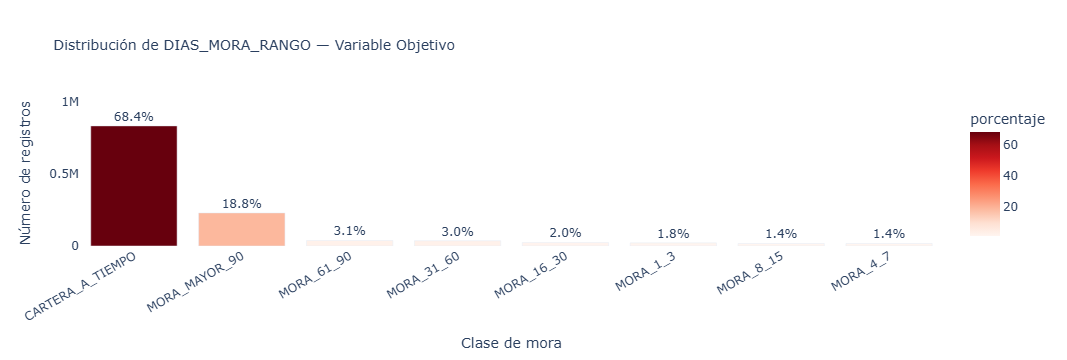


✓ Figura guardada en reports/figures/01_distribucion_target.png


In [8]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
dist_target = (
    df["DIAS_MORA_RANGO"]
    .value_counts(dropna=False)   # dropna=False para detectar nulos en el target
    .reset_index()
)
dist_target.columns = ["clase", "frecuencia"]
dist_target["porcentaje"] = (dist_target["frecuencia"] / len(df) * 100).round(2)
dist_target["frecuencia_fmt"] = dist_target["frecuencia"].apply(lambda x: f"{x:,}")

print("=== DISTRIBUCIÓN DE DIAS_MORA_RANGO ===\n")
display(dist_target.drop(columns="frecuencia_fmt"))

# ── Métricas de desbalance ────────────────────────────────────────────────────
n_clases          = dist_target["clase"].nunique()
frec_max          = dist_target["frecuencia"].max()
frec_min          = dist_target["frecuencia"].min()
clase_mayoritaria = dist_target.loc[dist_target["frecuencia"].idxmax(), "clase"]
clase_minoritaria = dist_target.loc[dist_target["frecuencia"].idxmin(), "clase"]
ratio_desbalance  = frec_max / frec_min

print(f"\nNúmero de clases detectadas  : {n_clases}")
print(f"Clase más frecuente          : '{clase_mayoritaria}' ({frec_max:,} filas)")
print(f"Clase menos frecuente        : '{clase_minoritaria}' ({frec_min:,} filas)")
print(f"Ratio de desbalance (max/min): {ratio_desbalance:.1f}x")

if ratio_desbalance > 10:
    print("\n⚠️  Desbalance > 10x — se activará is_unbalance=True en LightGBM (Sprint 5)")
else:
    print("\n✓ Desbalance moderado — class_weight puede ser suficiente")

# ── Visualización interactiva ─────────────────────────────────────────────────
fig = px.bar(
    dist_target,
    x="clase",
    y="frecuencia",
    text="porcentaje",
    title="Distribución de DIAS_MORA_RANGO — Variable Objetivo",
    labels={"clase": "Clase de mora", "frecuencia": "Número de registros"},
    color="porcentaje",
    color_continuous_scale="Reds",
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(
    xaxis_tickangle=-30,
    showlegend=False,
    title_font_size=14,
    plot_bgcolor="white",
)
fig.show()

# Guardar versión estática para el reporte ejecutivo
fig.write_image(str(FIG_DIR / "01_distribucion_target.png"), scale=2)
print("\n✓ Figura guardada en reports/figures/01_distribucion_target.png")


## 5. Cobertura temporal

Analizamos el volumen de registros por corte semanal (`HOY`) y por archivo fuente.

Este análisis es crítico para el **Sprint 2** donde definiremos la fecha de corte
del split temporal. Necesitamos:
- Confirmar que los datos de los dos archivos no se solapan
- Identificar períodos con volumen inusualmente bajo (posibles cortes incompletos)
- Establecer un rango de fechas confiable para el modelo


=== RESUMEN DE COBERTURA TEMPORAL ===
  Total de cortes semanales (HOY únicos) : 137
  Corte más antiguo                      : 2016-06-22
  Corte más reciente                     : 2019-01-30
  Promedio de registros por corte        : 8,897
  Promedio de asesores por corte         : 488
  Corte con más registros                : 2017-04-12 (9,668)
  Corte con menos registros              : 2018-11-07 (7,821)


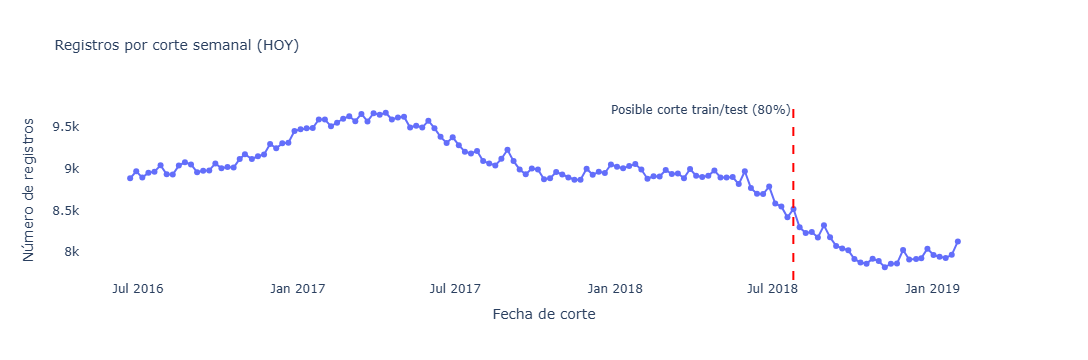

✓ Figura guardada en reports/figures/02_volumen_temporal.png


In [9]:
# ── Volumen de registros y asesores únicos por corte semanal ─────────────────
vol_semanal = (
    df.groupby("HOY")
    .agg(
        registros = ("CODIGO_ASESOR", "count"),    # total de filas por corte
        asesores  = ("CODIGO_ASESOR", "nunique"),   # asesores únicos por corte
    )
    .reset_index()
    .sort_values("HOY")
)

print("=== RESUMEN DE COBERTURA TEMPORAL ===")
print(f"  Total de cortes semanales (HOY únicos) : {vol_semanal['HOY'].nunique():,}")
print(f"  Corte más antiguo                      : {vol_semanal['HOY'].min().date()}")
print(f"  Corte más reciente                     : {vol_semanal['HOY'].max().date()}")
print(f"  Promedio de registros por corte        : {vol_semanal['registros'].mean():,.0f}")
print(f"  Promedio de asesores por corte         : {vol_semanal['asesores'].mean():,.0f}")
print(f"  Corte con más registros                : {vol_semanal.loc[vol_semanal['registros'].idxmax(), 'HOY'].date()} ({vol_semanal['registros'].max():,})")
print(f"  Corte con menos registros              : {vol_semanal.loc[vol_semanal['registros'].idxmin(), 'HOY'].date()} ({vol_semanal['registros'].min():,})")

# ── Gráfica de volumen a lo largo del tiempo ──────────────────────────────────
fig2 = px.line(
    vol_semanal,
    x="HOY",
    y="registros",
    title="Registros por corte semanal (HOY)",
    labels={"HOY": "Fecha de corte", "registros": "Número de registros"},
    markers=True,
)
fig2.update_layout(plot_bgcolor="white", title_font_size=14)
fig2.add_vline(
    # Línea vertical sugerida para el split temporal — se ajusta en Sprint 2
    x=vol_semanal["HOY"].quantile(0.8, interpolation="nearest").timestamp() * 1000,
    line_dash="dash",
    line_color="red",
    annotation_text="Posible corte train/test (80%)",
    annotation_position="top left",
)
fig2.show()

fig2.write_image(str(FIG_DIR / "02_volumen_temporal.png"), scale=2)
print("✓ Figura guardada en reports/figures/02_volumen_temporal.png")


## 6. Variables numéricas — estadísticas descriptivas y outliers

Calculamos estadísticas descriptivas completas y visualizamos boxplots para
detectar outliers. 

**Importante:** los outliers se documentan aquí pero **no se filtran en este sprint**.
El criterio de filtrado (IQR, percentil, o decisión de negocio) se decide en el
Sprint 3 de feature engineering, con justificación explícita por variable.


In [11]:
# ── Variables numéricas a analizar ───────────────────────────────────────────
# Excluimos IDs, fechas y variables de leakage
NUM_COLS = [
    "GRUPOS", "CLIENTES", "PRESTAMO", "CLIENTES_PRESTAMO",
    "CARTERA_HOY", "CARTERA_SEMANT", "INCREMENTO_CARTERA", "ATRASO",
    "TASA_PROM", "PROVISION_HOY", "PROVISION_SEMANT",
    "GASTO_PROVISION_SEMANAL", "DIAS_MORA", "CICLO", "EDAD",
    "CLIENTES_NUEVOS", "DESEMBOLSO_CLIENTES_NUEVOS",
]

# ── Estadísticas descriptivas ─────────────────────────────────────────────────
print("=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS ===\n")
desc = df[NUM_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc.columns = ["count","mean","std","min","p1","p5","p25","p50","p75","p95","p99","max"]
display(desc.round(2))

# ── Detección de outliers: IQR ────────────────────────────────────────────────
print("\n=== DETECCIÓN DE OUTLIERS (método IQR) ===\n")
print(f"{'Variable':<35} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lím. inf':>12} {'Lím. sup':>12} {'# outliers':>12} {'% outliers':>12}")
print("─" * 115)

outlier_report = []
for col in NUM_COLS:
    serie = df[col].dropna().astype(float)
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out   = int(((serie < lim_inf) | (serie > lim_sup)).sum())
    pct_out = n_out / len(serie) * 100
    print(f"{col:<35} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} {lim_inf:>12.2f} {lim_sup:>12.2f} {n_out:>12,} {pct_out:>11.1f}%")
    outlier_report.append({"variable": col, "n_outliers": n_out, "pct_outliers": pct_out})


=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS ===



,count,mean,std,min,p1,p5,p25,p50,p75,p95,p99,max
GRUPOS,"1,218,831.0000",1.0100,0.1300,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,10.0000
CLIENTES,"1,218,831.0000",9.7000,2.6700,1.0000,3.0000,7.0000,8.0000,10.0000,11.0000,14.0000,20.0000,62.0000
PRESTAMO,"1,218,831.0000","6,950.9400","35,611.5000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"51,000.0000","180,000.0000","1,828,000.0000"
CLIENTES_PRESTAMO,"1,218,831.0000",0.5800,2.4500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,11.0000,62.0000
CARTERA_HOY,"1,218,831.0000","57,375.7000","60,602.3800",0.0000,"1,238.0100","4,959.3300","19,932.8100","40,150.3900","72,075.3600","171,000.0000","298,889.0900","1,828,000.0000"
CARTERA_SEMANT,"1,218,831.0000","55,321.1300","60,705.6900",0.0000,0.0000,0.0000,"17,704.0500","38,863.6400","70,817.8100","169,044.7300","295,349.1300","1,172,000.0000"
INCREMENTO_CARTERA,"1,218,831.0000","2,054.5700","35,101.0000","-447,000.0000","-26,773.2500","-15,879.4300","-6,742.0100","-3,370.1000",0.0000,"48,729.6500","168,000.0000","1,828,000.0000"
ATRASO,"1,218,831.0000","8,355.5300","21,873.2900",0.0000,0.0000,0.0000,0.0000,0.0000,"5,735.1900","46,691.7600","97,887.5400","615,376.7600"
TASA_PROM,"1,218,831.0000",209.0100,68.7800,0.0000,82.5600,89.7300,151.9200,219.6600,262.4300,317.4500,355.4900,355.4900
PROVISION_HOY,"1,218,831.0000","7,326.3000","17,472.9800",0.0000,50.6400,140.9900,475.5900,"1,110.4800","4,914.2900","37,250.6600","78,990.6800","658,601.4900"



=== DETECCIÓN DE OUTLIERS (método IQR) ===

Variable                                    Q1         Q3        IQR     Lím. inf     Lím. sup   # outliers   % outliers
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
GRUPOS                                    1.00       1.00       0.00         1.00         1.00       16,842         1.4%
CLIENTES                                  8.00      11.00       3.00         3.50        15.50       50,514         4.1%
PRESTAMO                                  0.00       0.00       0.00         0.00         0.00       70,437         5.8%
CLIENTES_PRESTAMO                         0.00       0.00       0.00         0.00         0.00       70,437         5.8%
CARTERA_HOY                           19932.81   72075.36   52142.54    -58281.00    150289.18       82,130         6.7%
CARTERA_SEMANT                        17704.05   70817.81   53113.76    -61966.59    150488.45       79,559      

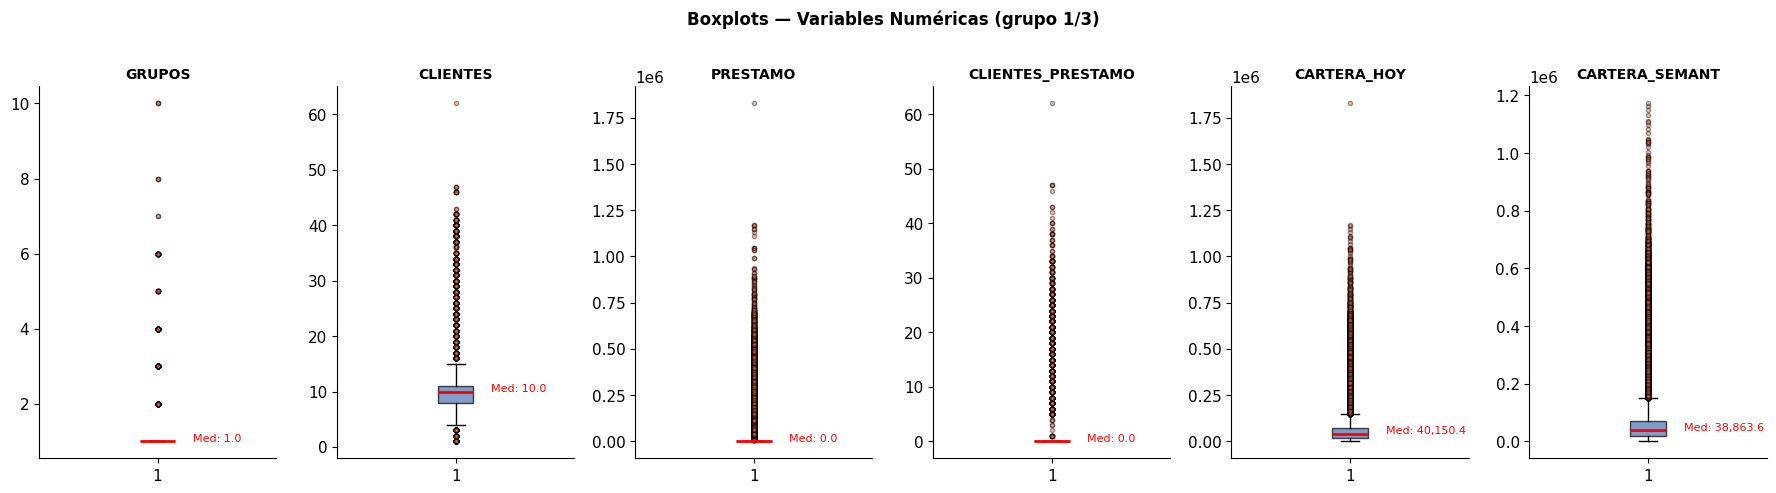

✓ Guardado: 03_boxplots_numericas_g1.png


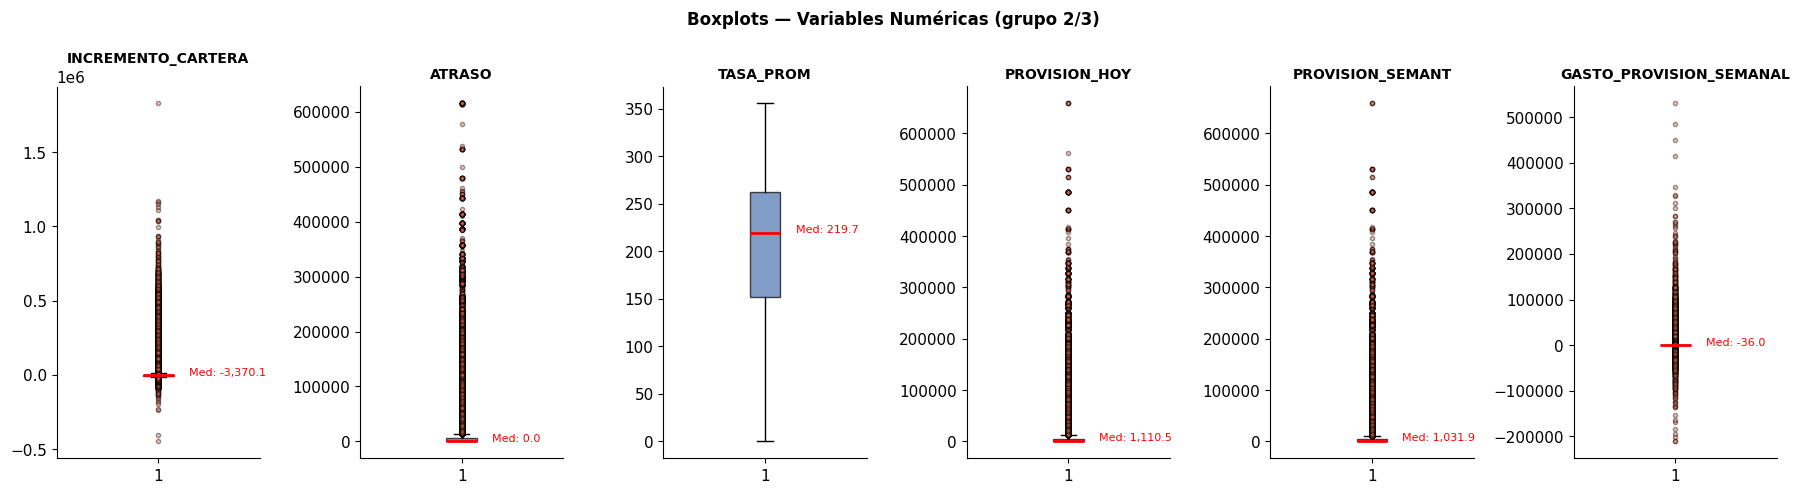

✓ Guardado: 03_boxplots_numericas_g2.png


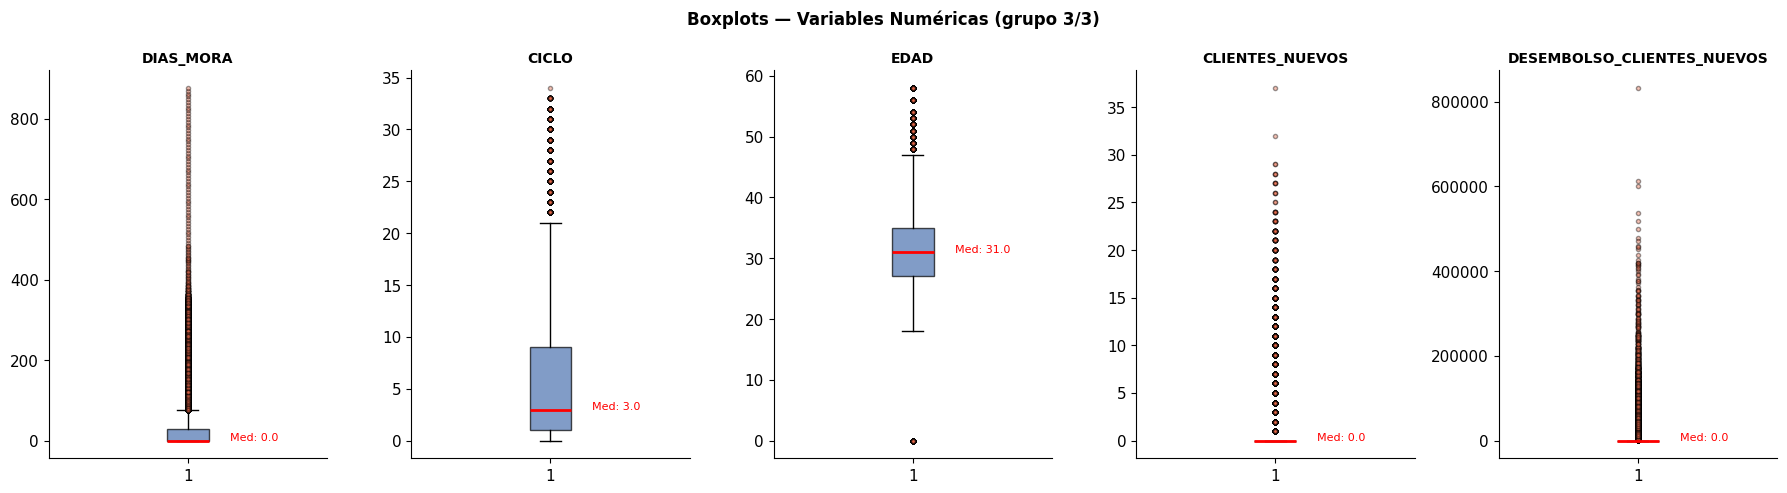

✓ Guardado: 03_boxplots_numericas_g3.png


In [12]:
# ── Boxplots para visualización de outliers ───────────────────────────────────
# Se grafican en grupos de 6 para mejor legibilidad

grupos = [NUM_COLS[i:i+6] for i in range(0, len(NUM_COLS), 6)]

for g_idx, grupo in enumerate(grupos):
    fig3, axes = plt.subplots(1, len(grupo), figsize=(18, 5))
    if len(grupo) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, grupo):
        datos = df[col].dropna().astype(float)
        bp = ax.boxplot(
            datos,
            vert=True,
            patch_artist=True,
            boxprops    = dict(facecolor="#4C72B0", alpha=0.7),
            medianprops = dict(color="red", linewidth=2),
            flierprops  = dict(marker="o", markerfacecolor="#E8694A",
                               markersize=3, alpha=0.4),
        )
        ax.set_title(col, fontsize=10, fontweight="bold")
        # Anotar la mediana
        mediana = datos.median()
        ax.annotate(f"Med: {mediana:,.1f}", xy=(1, mediana),
                    xytext=(1.15, mediana), fontsize=8, color="red")
    
    plt.suptitle(f"Boxplots — Variables Numéricas (grupo {g_idx+1}/{len(grupos)})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    fname = FIG_DIR / f"03_boxplots_numericas_g{g_idx+1}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Guardado: {fname.name}")


## 7. Variables categóricas — frecuencias e inconsistencias

Revisamos la distribución de cada variable categórica para detectar:
- Valores inesperados (como `'VENCIDOS'` en `SEMANA_ACTUAL_RANGO`)
- Categorías con muy pocas observaciones (riesgo en el modelo)
- Inconsistencias de escritura (mayúsculas/minúsculas, espacios)

Las variables marcadas con ⚠️ **FAIRNESS** requieren análisis de equidad
antes de incorporarse al modelo (Sprint 6).


In [13]:
# ── Variables categóricas a revisar ─────────────────────────────────────────
CAT_COLS = {
    # Variable           : descripción y notas
    "REGION"             : "Región geográfica",
    "RANGO_CICLO"        : "Ciclo crediticio agrupado",
    "SEMANA_ACTUAL_RANGO": "⚠️ Requiere limpieza — valor 'VENCIDOS' detectado",
    "PUESTO"             : "Cargo del asesor",
    "PRODUCTO"           : "Tipo de producto crediticio",
    "AREA"               : "Área geográfica",
    "TIPO_BAJA"          : "Tipo de baja (puede tener muchos nulos si el asesor sigue activo)",
    "MOTIVO_BAJA"        : "Motivo de baja",
    "SEXO"               : "⚠️ FAIRNESS — género del asesor",
    "ESTADO_CIVIL"       : "⚠️ FAIRNESS — estado civil",
    "EXP_MICROFINANZAS"  : "Experiencia previa en el sector",
    "NIVEL_ESTUDIOS"     : "Máximo nivel educativo",
}

for col, descripcion in CAT_COLS.items():
    vals  = df[col].value_counts(dropna=False)
    n_uni = df[col].nunique(dropna=True)
    n_nul = df[col].isna().sum()
    
    print(f"\n{'═'*60}")
    print(f"  {col}  —  {descripcion}")
    print(f"  Valores únicos: {n_uni}  |  Nulos: {n_nul:,} ({n_nul/len(df)*100:.1f}%)")
    print(f"{'─'*60}")
    
    # Calcular porcentaje para cada categoría
    df_vals = vals.reset_index()
    df_vals.columns = ["valor", "frecuencia"]
    df_vals["porcentaje"] = (df_vals["frecuencia"] / len(df) * 100).round(2)
    print(df_vals.to_string(index=False))
    
    # Advertencia si hay categorías con < 30 observaciones
    minima = vals.min()
    if minima < 30:
        print(f"\n  ⚠️  Categoría con solo {minima} observaciones — riesgo en validación cruzada")



════════════════════════════════════════════════════════════
  REGION  —  Región geográfica
  Valores únicos: 9  |  Nulos: 28 (0.0%)
────────────────────────────────────────────────────────────
            valor  frecuencia  porcentaje
Oriente - Morelos      271887     22.3100
            Golfo      153980     12.6300
          Cumbres      149661     12.2800
        Altiplano      143477     11.7700
            Bajio      139209     11.4200
       Sur Oaxaca      110074      9.0300
  Centro Poniente      103908      8.5300
           Centro       87217      7.1600
     Sur Veracruz       59390      4.8700
             None          28      0.0000

  ⚠️  Categoría con solo 28 observaciones — riesgo en validación cruzada

════════════════════════════════════════════════════════════
  RANGO_CICLO  —  Ciclo crediticio agrupado
  Valores únicos: 6  |  Nulos: 0 (0.0%)
────────────────────────────────────────────────────────────
        valor  frecuencia  porcentaje
CICLO_MAYOR_5      47116

## 8. Verificación de variables de leakage

`PASE1`, `PASE15` y `PASE30` son variables **contemporáneas al target**: se miden
en el mismo corte temporal que `DIAS_MORA_RANGO`. Incluirlas en el modelo equivale
a predecir la mora con información de la mora misma — invalidaría cualquier
evaluación fuera de muestra.

Esta sección confirma su exclusión con evidencia cuantitativa.


In [14]:
LEAKAGE_COLS = ["PASE1", "PASE15", "PASE30"]

print("=== VERIFICACIÓN DE VARIABLES DE LEAKAGE ===\n")
print("Estas variables son contemporáneas al target y DEBEN EXCLUIRSE del modelo.\n")

for col in LEAKAGE_COLS:
    serie     = df[col].dropna()
    n_cero    = (df[col] == 0).sum()
    pct_cero  = n_cero / len(df) * 100
    n_nulos   = df[col].isna().sum()
    pct_nulos = n_nulos / len(df) * 100
    
    print(f"  {col}:")
    print(f"    Nulos          : {n_nulos:,} ({pct_nulos:.1f}%)")
    print(f"    Valor cero     : {n_cero:,} ({pct_cero:.1f}%)")
    print(f"    Mín / Máx      : {serie.min()} / {serie.max()}")
    print(f"    Distribución   : {dict(df[col].value_counts(dropna=False).head(5))}")
    print(f"    → EXCLUIDA ❌\n")

print("Registro formal: estas columnas se excluyen en el ColumnTransformer del Sprint 3.")


=== VERIFICACIÓN DE VARIABLES DE LEAKAGE ===

Estas variables son contemporáneas al target y DEBEN EXCLUIRSE del modelo.

  PASE1:
    Nulos          : 0 (0.0%)
    Valor cero     : 1,196,700 (98.2%)
    Mín / Máx      : 0.0 / 565281.47
    Distribución   : {0.0: np.int64(1196700), 56000.0: np.int64(9), 40000.0: np.int64(8), 45000.0: np.int64(8), 59000.0: np.int64(7)}
    → EXCLUIDA ❌

  PASE15:
    Nulos          : 0 (0.0%)
    Valor cero     : 1,209,122 (99.2%)
    Mín / Máx      : 0.0 / 518000.0
    Distribución   : {0.0: np.int64(1209122), 23661.11: np.int64(3), 12261.04: np.int64(3), 12448.04: np.int64(3), 19859.11: np.int64(2)}
    → EXCLUIDA ❌

  PASE30:
    Nulos          : 0 (0.0%)
    Valor cero     : 1,209,874 (99.3%)
    Mín / Máx      : 0.0 / 518000.0
    Distribución   : {0.0: np.int64(1209874), 23661.11: np.int64(4), 26074.56: np.int64(3), 20205.9: np.int64(3), 8377.82: np.int64(3)}
    → EXCLUIDA ❌

Registro formal: estas columnas se excluyen en el ColumnTransformer del

## 9. Decisiones de diseño — registro formal

Esta sección es el **registro oficial** de las decisiones tomadas con base en el EDA.
Se copia directamente a `METHODOLOGY.md` en el repositorio.

Ninguna decisión tomada aquí debe modificarse en sprints posteriores sin
documentar el cambio y la justificación.


In [15]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         DECISIONES DE DISEÑO — SPRINT 1 EDA                    ║
║         Fuente: análisis del dataset completo                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VARIABLE OBJETIVO                                               ║
║  → DIAS_MORA_RANGO como target principal (nivel semanal)        ║
║  → Target_B a nivel asesor (TDNC cuartiles) se define           ║
║    en Sprint 2 con base en el conteo real de asesores únicos    ║
║                                                                  ║
║  VARIABLES EXCLUIDAS — LEAKAGE CONTEMPORÁNEO                    ║
║  → PASE1  : % cartera 1 día mora (mismo corte que target)      ║
║  → PASE15 : % cartera 15 días mora (mismo corte que target)    ║
║  → PASE30 : % cartera 30 días mora (mismo corte que target)    ║
║                                                                  ║
║  VARIABLES DE FAIRNESS (análisis obligatorio en Sprint 6)       ║
║  → SEXO, EDAD, ESTADO_CIVIL                                     ║
║  → No se usan en el modelo sin análisis de disparidad previo   ║
║                                                                  ║
║  MÉTRICA DE EVALUACIÓN PRINCIPAL                                 ║
║  → Macro F1 (no accuracy global)                                ║
║  → Justificación: accuracy es engañoso con clases desbalanceadas║
║  → Métricas secundarias: Cohen Kappa, AUC OvR macro            ║
║                                                                  ║
║  MANEJO DE DESBALANCE                                            ║
║  → LightGBM: is_unbalance=True                                  ║
║  → Logistic Regression: class_weight='balanced'                 ║
║  → XGBoost: scale_pos_weight por clase                          ║
║                                                                  ║
║  OUTLIERS                                                        ║
║  → Documentados en este sprint, NO filtrados                    ║
║  → Decisión de filtrado: Sprint 3 (feature engineering)        ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║         DECISIONES DE DISEÑO — SPRINT 1 EDA                    ║
║         Fuente: análisis del dataset completo                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VARIABLE OBJETIVO                                               ║
║  → DIAS_MORA_RANGO como target principal (nivel semanal)        ║
║  → Target_B a nivel asesor (TDNC cuartiles) se define           ║
║    en Sprint 2 con base en el conteo real de asesores únicos    ║
║                                                                  ║
║  VARIABLES EXCLUIDAS — LEAKAGE CONTEMPORÁNEO                    ║
║  → PASE1  : % cartera 1 día mora (mismo corte que target)      ║
║  → PASE15 : % cartera 15 días mora (mismo corte que target)    ║
║  → PASE30 : % cartera 30 días mora (mismo corte que target)    ║
║                                             